# Figure 2
## Enrichment of PCG around ncRNA's TSS
### Author: Martin Loza
### Date: 25/12/08

In this Figure we explore the enrichment of protein coding gene around the TSS of ncRNA.

In [20]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "251208"
red = "#E41A1C"
blue = "#377EB8"
text_size = 18
width = 4
height = 3
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/distances/single_pcg_gene_transcripts/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/02_Figure_2/Plots/"

# Function to visualize the enrichment of PCG's TSS near ncRNA's TSS
plot_pcg_ncrna_distribution <- function(data, 
                                        distance_column = "strand_distance", fill_column = "ncrna_strand",
                                        window_size = 10000, bin_width = 50, alpha = 0.6, text_size = 12,
                                        species_name = "Species") {
    # Filter distances within the specified window size
    filtered_data <- data %>%
        filter(!!sym(distance_column) >= -window_size & !!sym(distance_column) <= window_size)
    
    # Set the fill column as a factor
    filtered_data[[fill_column]] <- factor(as.character(filtered_data[[fill_column]]), levels = c("1", "-1"))

    # Create the histogram plot
    p <- filtered_data %>%
        ggplot(aes_string(x = distance_column, fill = fill_column)) +
        geom_histogram(position = "dodge",binwidth = bin_width, alpha = alpha) +
        scale_fill_manual(values = c("1" = blue, 
                                 "-1" = red),
                      labels = c("1" = "Forward", "-1" = "Reverse")) +
        theme_minimal() + 
        labs(title = str_to_title(species_name),
            x = "Distance from ncRNA TSS (bp)",
            y = "Counts") +
        theme(text = element_text(size = text_size),
              plot.title = element_text(hjust = 0.5, size = 14),
              legend.title = element_blank()) + 
        guides(fill = guide_legend(override.aes = list(alpha = 1)))

    return(p)
}

### Load and setup the data

In [2]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["dog"]], 3)


,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,1,ENSCAFT00845000004,41931353,,1,lncRNA,ENSCAFT00845037491,AKAP12,41882972,-48381,-48381
2,1,ENSCAFT00845000004,41931353,,1,lncRNA,ENSCAFT00845000019,ARMT1,41984839,53486,53486
3,1,ENSCAFT00845000004,41931353,,1,lncRNA,ENSCAFT00845000026,CCDC170,42020714,89361,89361


In [3]:
names(data_list)

[1] "armadillo"  "chicken"    "dog"        "drosophila" "elegans"   
 [6] "ferret"     "human"      "macaque"    "mouse"      "rat"       
[11] "zebrafish"

In [4]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse", "macaque", 
                     "rat", "zebrafish", "ferret", 
                     "dog", "chicken", "armadillo", 
                     "drosophila", "elegans")

# Arrange the data_list according to the ordered_species
data_list <- data_list[ordered_species]

### Figure

In [15]:
# Get the plot for a specific species
plots_list = list()
for (species in names(data_list)) {
    plots_list[[species]] <- plot_pcg_ncrna_distribution(data_list[[species]], species_name = species,
                                                         window_size = 10000, bin_width = 250, alpha = 0.6, text_size = 14)
}

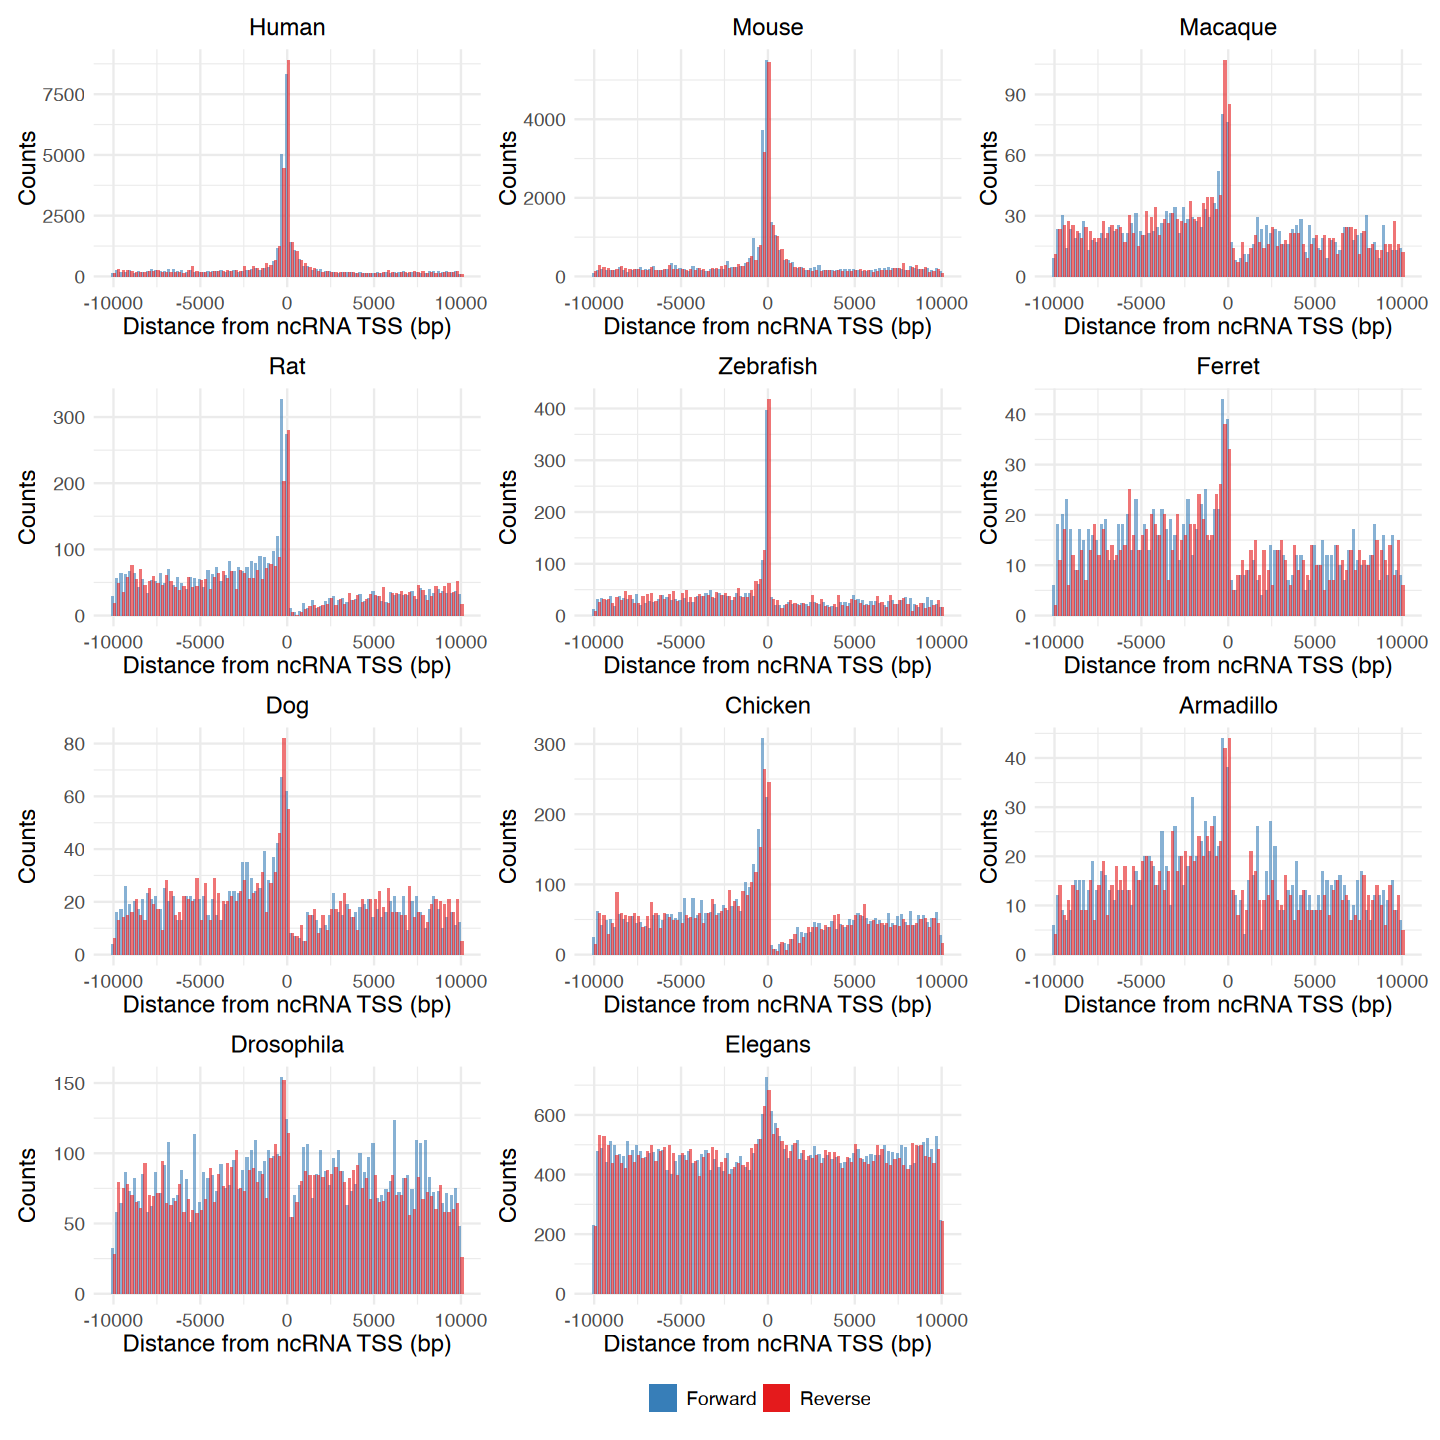

In [26]:
# Merge all plots into a single figure
options(repr.plot.width=12, repr.plot.height=12)
figure_2a <- wrap_plots(plots_list, ncol = 3) + plot_layout(guides = "collect") & theme(legend.position = 'bottom')
figure_2a

In [27]:
# Save the figure as PDF
ggsave(filename = file.path(out_dir, paste0("Figure_2a_", date, ".pdf")),
    plot = figure_2a, 
    width = width*3, height = height * 4, units = "in", dpi = dpi)

Now, let's get the Figure 2b

NOTE: THIS FIGURE HAS CHANGE/REMOVED IN THE LATEST VERSION

In [22]:
# Get the selected species and select only lncRNA genes
sel_species <- c("human", "mouse")
selected_species <- data_list[sel_species]

# select distance related to lncRNA genes only
for (species in names(selected_species)) {
    selected_species[[species]] <- selected_species[[species]] %>%
        filter(gene_biotype == "lncRNA")
}

In [23]:
# Get the plot for a specific species
selected_plot_list = list()
for (species in names(selected_species)) {
    selected_plot_list[[species]] <- plot_pcg_ncrna_distribution(selected_species[[species]], species_name = species,
                                                         window_size = 10000, bin_width = 250, alpha = 0.6, text_size = 14)
}

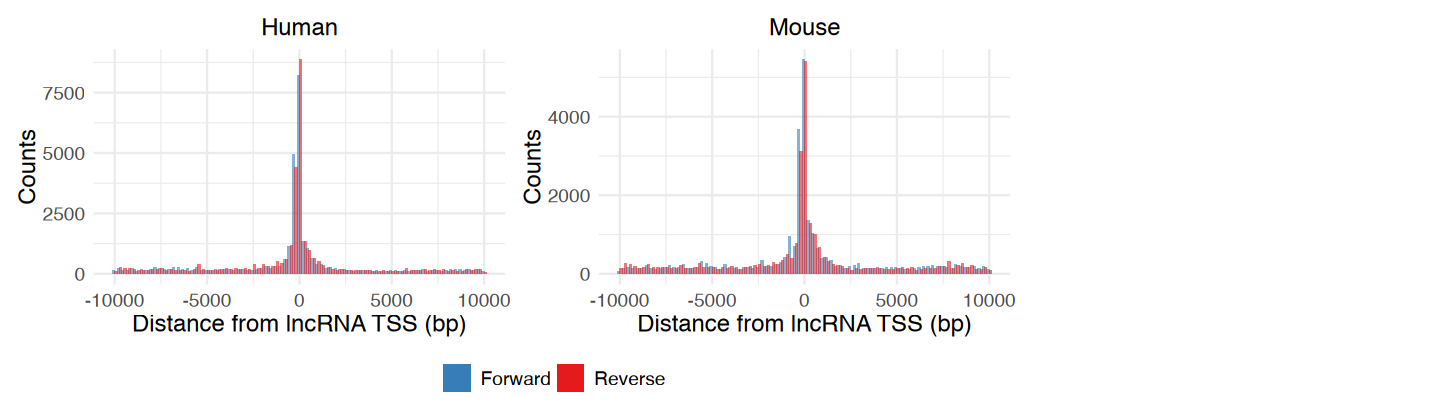

In [24]:
# Merge selected plots into a single figure
options(repr.plot.width=12, repr.plot.height=3.5)
figure_2b <- wrap_plots(selected_plot_list, ncol = 3, guides = "collect") & 
    theme(legend.position = 'bottom') & 
    labs(x = "Distance from lncRNA TSS (bp)")
figure_2b

In [29]:
# Save the figure as PDF
ggsave(filename = file.path(out_dir, paste0("Figure_2b_", date, ".pdf")),
    plot = figure_2b, 
    width = width*3, height = (height * 1) + 0.75, units = "in", dpi = dpi)